In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

df = pd.read_csv("chord-fingers.csv", delimiter=";", encoding="UTF-8")

print(f"Data length : {len(df)}")

print("\nData information")
df.info()

print("\nChecking null data")
print(df.isnull().sum())

Data length : 2632

Data information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2632 entries, 0 to 2631
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CHORD_ROOT        2632 non-null   object
 1   CHORD_TYPE        2632 non-null   object
 2   CHORD_STRUCTURE   2632 non-null   object
 3   FINGER_POSITIONS  2632 non-null   object
 4   NOTE_NAMES        2632 non-null   object
dtypes: object(5)
memory usage: 102.9+ KB

Checking null data
CHORD_ROOT          0
CHORD_TYPE          0
CHORD_STRUCTURE     0
FINGER_POSITIONS    0
NOTE_NAMES          0
dtype: int64




---




> **Data Cleaning**



---




In [ ]:
df.head(50)

,CHORD_ROOT,CHORD_TYPE,CHORD_STRUCTURE,FINGER_POSITIONS,NOTE_NAMES
0,A#,13,1;3;5;b7;9;11;13,"x,1,0,2,3,4","A#,C##,G#,B#,F##"
1,A#,13,1;3;5;b7;9;11;13,"4,x,3,2,1,1","A#,G#,B#,C##,F##"
2,A#,13,1;3;5;b7;9;11;13,"1,x,1,2,3,4","A#,G#,C##,F##,B#"
3,A#,7(#9),1;3;5;b7;#9,"x,1,0,2,4,3","A#,C##,G#,B##,E#"
4,A#,7(#9),1;3;5;b7;#9,"2,1,3,3,3,x","A#,C##,G#,B##,E#"
5,A#,7(#9),1;3;5;b7;#9,"1,3,1,2,1,4","A#,E#,G#,C##,E#,B##"
6,A#,9,1;3;5;b7;9,"x,2,0,3,4,x","A#,C##,G#,B#"
7,A#,9,1;3;5;b7;9,"x,1,3,2,4,x","C##,G#,B#,E#"
8,A#,9,1;3;5;b7;9,"1,x,1,2,1,4","A#,G#,C##,E#,B#"
9,A#,9b5,1;3;b5;b7;9,"0,1,0,2,3,0","E,A#,C##,G#,B#,E"


In [ ]:
df.columns

Index(['CHORD_ROOT', 'CHORD_TYPE', 'CHORD_STRUCTURE', 'FINGER_POSITIONS',
       'NOTE_NAMES'],
      dtype='object')

In [ ]:
df["CHORD_ROOT"].unique()

array(['A#', 'C#', 'D#', 'F#', 'G#', 'Ab', 'Bb', 'Cb', 'Db', 'Eb', 'Gb',
       'A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype=object)

In [ ]:
chord_counts = df['CHORD_ROOT'].value_counts()

print(chord_counts)
chord_counts.sum()

CHORD_ROOT
A     233
C     226
G     224
D     223
E     220
Bb    197
F     170
B     153
C#    134
Ab    132
Eb    129
F#    126
Db    116
G#     98
Gb     92
D#     82
A#     76
Cb      1
Name: count, dtype: int64


2632

In [ ]:
chord_type = df.CHORD_TYPE.unique()

print(chord_type)

['13' '7(#9)' '9' '9b5' '7' 'dim7' 'aug' 'maj' '11' 'maj9' 'm' '7b5' 'm7'
 'dim' '6' '7(#5)' '7sus4' 'maj7' '5' 'm6' '7(b9)' 'm9' 'sus4' '6/9' 'm11'
 'm7b5' '9(#11)' '9(#5)' '7(#11)' 'maj13' '6(#11)' 'sus2' 'm(maj7)'
 '13(b9)' '+(#11)' '13(#11)' '7(b13)' 'add9' '13(#9)' 'm13' 'm6/9'
 'm(maj9)']


In [ ]:
chord_type_counts = df.CHORD_TYPE.value_counts()

print(chord_type_counts)
chord_type_counts.sum()

CHORD_TYPE
7          208
maj        203
m7         177
m          154
dim7       142
maj7       137
6          134
13         113
5          108
9          105
dim         86
m11         82
7(b9)       81
m9          74
maj9        70
aug         69
7(#9)       68
m6          66
7(#5)       64
6/9         64
sus4        63
7sus4       58
7b5         51
11          51
9b5         51
7(#11)      24
sus2        22
m7b5        21
maj13       21
add9        17
13(b9)      12
m(maj7)     10
9(#5)        6
9(#11)       5
m13          3
m6/9         3
+(#11)       2
13(#11)      2
m(maj9)      2
6(#11)       1
7(b13)       1
13(#9)       1
Name: count, dtype: int64


2632

In [ ]:
df.columns

Index(['CHORD_ROOT', 'CHORD_TYPE', 'CHORD_STRUCTURE', 'FINGER_POSITIONS',
       'NOTE_NAMES'],
      dtype='object')

In [ ]:
df["CHORD_ROOT"].unique()

array(['A#', 'C#', 'D#', 'F#', 'G#', 'Ab', 'Bb', 'Cb', 'Db', 'Eb', 'Gb',
       'A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype=object)

In [ ]:
chord_type_counts_AHash = df[df['CHORD_ROOT'] == "A#"].groupby('CHORD_ROOT')['CHORD_TYPE'].value_counts()

print(chord_type_counts_AHash)
chord_type_counts_AHash.sum()

CHORD_ROOT  CHORD_TYPE
A#          dim7          8
            m             4
            11            3
            13            3
            maj9          3
            maj7          3
            maj           3
            m9            3
            m7            3
            m6            3
            dim           3
            aug           3
            9b5           3
            9             3
            7sus4         3
            7b5           3
            7(b9)         3
            7(#9)         3
            7(#5)         3
            7             3
            6/9           3
            6             3
            sus4          3
            5             1
Name: count, dtype: int64


76

In [ ]:
df.columns

Index(['CHORD_ROOT', 'CHORD_TYPE', 'CHORD_STRUCTURE', 'FINGER_POSITIONS',
       'NOTE_NAMES'],
      dtype='object')

In [ ]:
df.head()

,CHORD_ROOT,CHORD_TYPE,CHORD_STRUCTURE,FINGER_POSITIONS,NOTE_NAMES
0,A#,13,1;3;5;b7;9;11;13,"x,1,0,2,3,4","A#,C##,G#,B#,F##"
1,A#,13,1;3;5;b7;9;11;13,"4,x,3,2,1,1","A#,G#,B#,C##,F##"
2,A#,13,1;3;5;b7;9;11;13,"1,x,1,2,3,4","A#,G#,C##,F##,B#"
3,A#,7(#9),1;3;5;b7;#9,"x,1,0,2,4,3","A#,C##,G#,B##,E#"
4,A#,7(#9),1;3;5;b7;#9,"2,1,3,3,3,x","A#,C##,G#,B##,E#"


In [ ]:
plt.rcParams['figure.figsize'] = (20,7)

Found redundant feature characteristics between the CHORD_TYPE and CHORD_STRUCTURE columns, as both represent corresponding information.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41],
 [Text(0, 0, '1;3;5;b7;9;11;13'),
  Text(1, 0, '1;3;5;b7;#9'),
  Text(2, 0, '1;3;5;b7;9'),
  Text(3, 0, '1;3;b5;b7;9'),
  Text(4, 0, '1;3;5;b7'),
  Text(5, 0, '1;b3;b5;bb7'),
  Text(6, 0, '1;3;#5'),
  Text(7, 0, '1;3;5'),
  Text(8, 0, '1;3;5;b7;9;11'),
  Text(9, 0, '1;3;5;7;9'),
  Text(10, 0, '1;b3;5'),
  Text(11, 0, '1;3;b5;b7'),
  Text(12, 0, '1;b3;5;b7'),
  Text(13, 0, '1;b3;b5'),
  Text(14, 0, '1;3;5;6'),
  Text(15, 0, '1;3;#5;b7'),
  Text(16, 0, '1;4;5;b7'),
  Text(17, 0, '1;3;5;7'),
  Text(18, 0, '1;5'),
  Text(19, 0, '1;b3;5;6'),
  Text(20, 0, '1;3;5;b7;b9'),
  Text(21, 0, '1;b3;5;b7;9'),
  Text(22, 0, '1;4;5'),
  Text(23, 0, '1;3;5;6;9'),
  Text(24, 0, '1;b3;5;b7;9;11'),
  Text(25, 0, '1;b3;b5;b7'),
  Text(26, 0, '1;3;5;b7;9;#11'),
  Text(

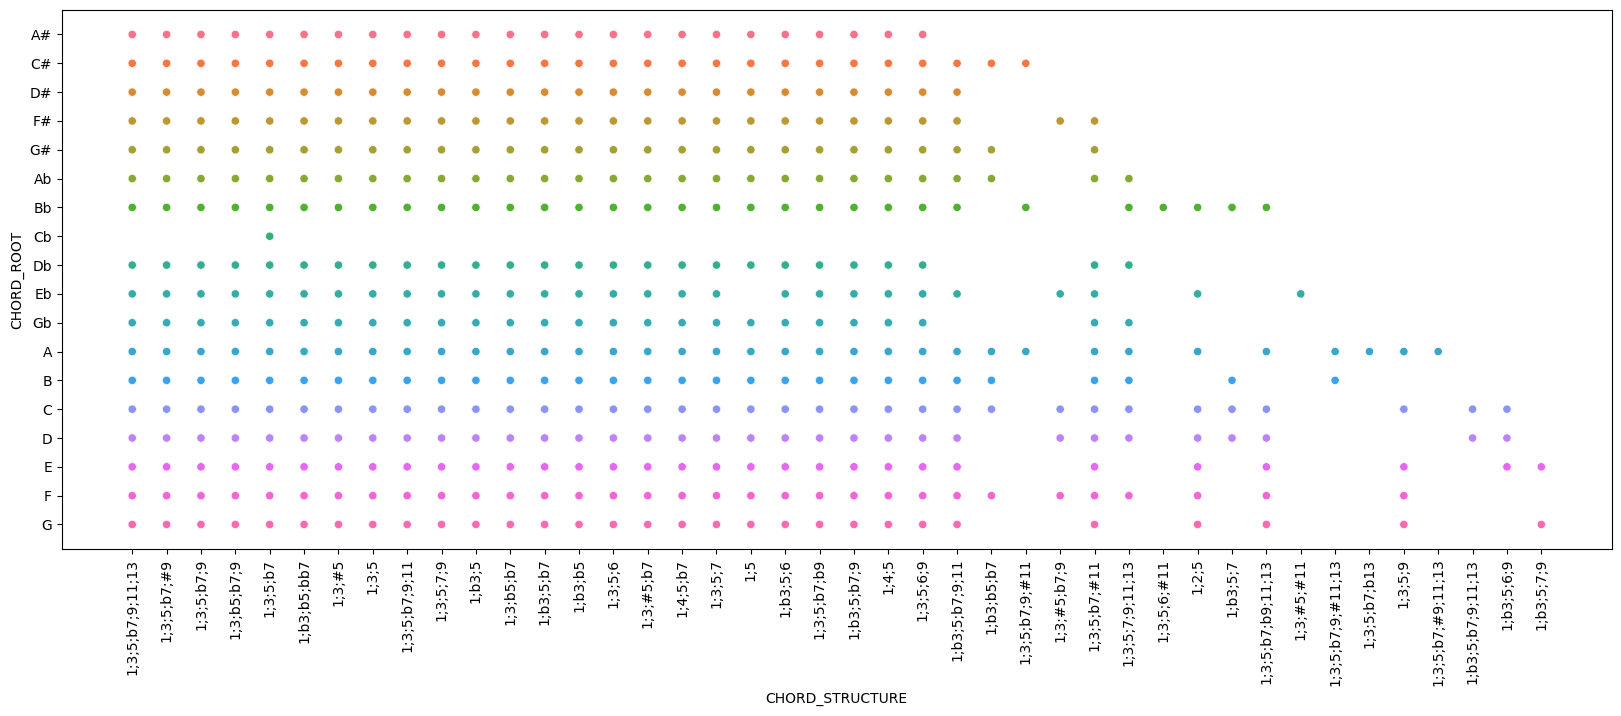

In [ ]:
sns.scatterplot(data=df, x='CHORD_STRUCTURE', y='CHORD_ROOT',hue= 'CHORD_ROOT',legend = False )
plt.xticks(rotation=90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41],
 [Text(0, 0, '13'),
  Text(1, 0, '7(#9)'),
  Text(2, 0, '9'),
  Text(3, 0, '9b5'),
  Text(4, 0, '7'),
  Text(5, 0, 'dim7'),
  Text(6, 0, 'aug'),
  Text(7, 0, 'maj'),
  Text(8, 0, '11'),
  Text(9, 0, 'maj9'),
  Text(10, 0, 'm'),
  Text(11, 0, '7b5'),
  Text(12, 0, 'm7'),
  Text(13, 0, 'dim'),
  Text(14, 0, '6'),
  Text(15, 0, '7(#5)'),
  Text(16, 0, '7sus4'),
  Text(17, 0, 'maj7'),
  Text(18, 0, '5'),
  Text(19, 0, 'm6'),
  Text(20, 0, '7(b9)'),
  Text(21, 0, 'm9'),
  Text(22, 0, 'sus4'),
  Text(23, 0, '6/9'),
  Text(24, 0, 'm11'),
  Text(25, 0, 'm7b5'),
  Text(26, 0, '9(#11)'),
  Text(27, 0, '9(#5)'),
  Text(28, 0, '7(#11)'),
  Text(29, 0, 'maj13'),
  Text(30, 0, '6(#11)'),
  Text(31, 0, 'sus2'),
  Text(32, 0, 'm(maj7)'),
  Text(33, 0, '13(b9)'),


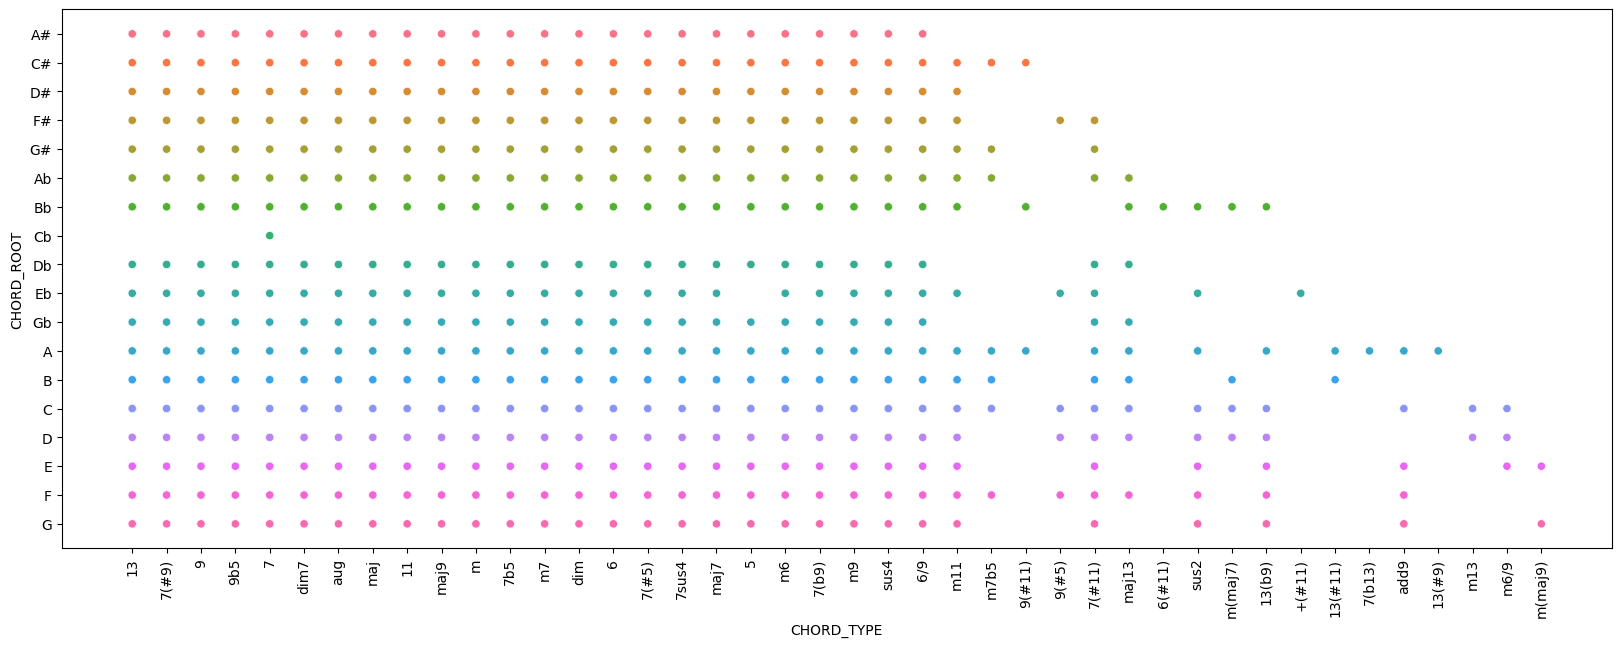

In [ ]:
sns.scatterplot(data=df, x='CHORD_TYPE', y='CHORD_ROOT',hue= 'CHORD_ROOT',legend = False )
plt.xticks(rotation=90)

From plotting both columns, data points overlap in a 1-to-1 manner, indicating that both columns describe the exact same information. Therefore, one of them can be removed. Ultimately, CHORD_STRUCTURE is dropped.

In [ ]:
df = df.drop(['CHORD_STRUCTURE'], axis=1)

In [ ]:
df.columns

Index(['CHORD_ROOT', 'CHORD_TYPE', 'FINGER_POSITIONS', 'NOTE_NAMES'], dtype='object')

In [ ]:
df.head()

,CHORD_ROOT,CHORD_TYPE,FINGER_POSITIONS,NOTE_NAMES
0,A#,13,"x,1,0,2,3,4","A#,C##,G#,B#,F##"
1,A#,13,"4,x,3,2,1,1","A#,G#,B#,C##,F##"
2,A#,13,"1,x,1,2,3,4","A#,G#,C##,F##,B#"
3,A#,7(#9),"x,1,0,2,4,3","A#,C##,G#,B##,E#"
4,A#,7(#9),"2,1,3,3,3,x","A#,C##,G#,B##,E#"


Plotting columns to explore feature relationships and select suitable features for Machine Learning models.

<Axes: xlabel='CHORD_TYPE', ylabel='NOTE_NAMES'>

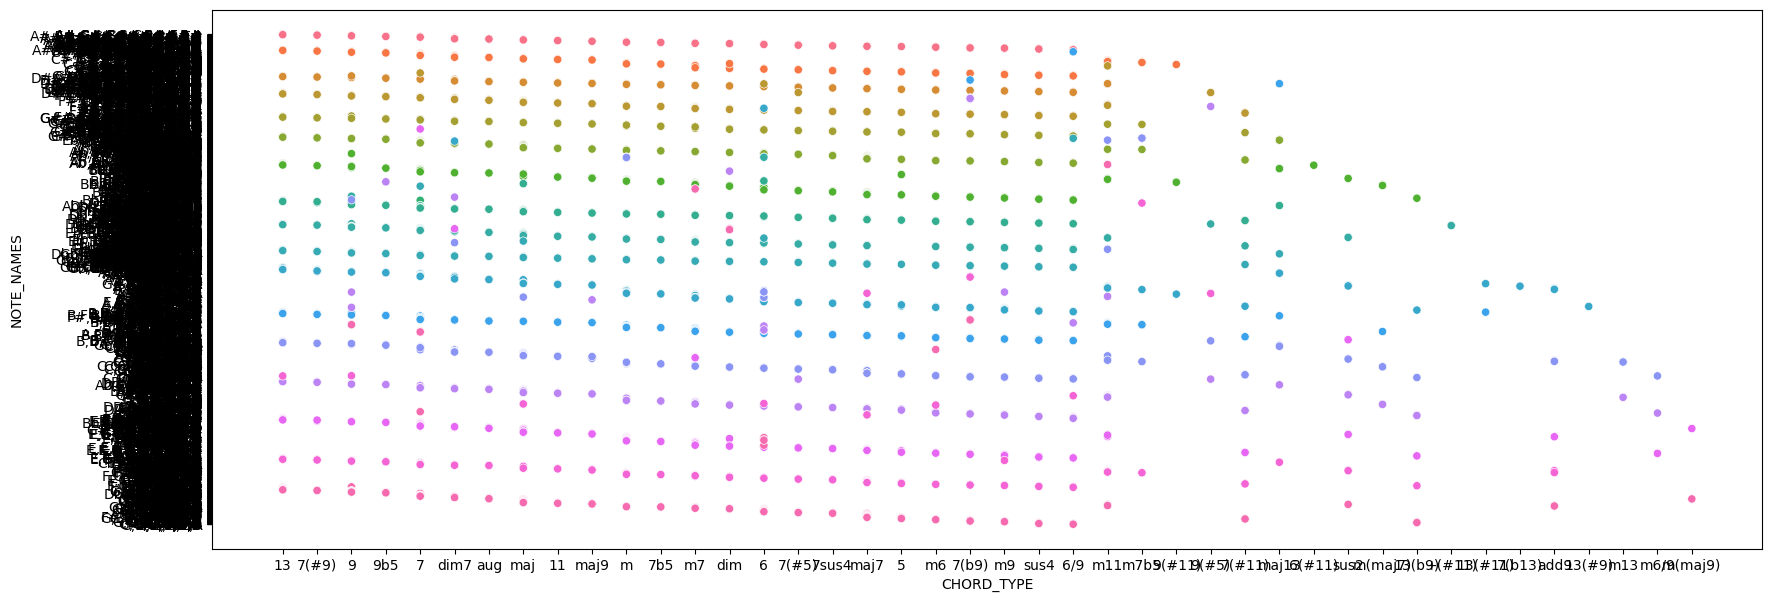

In [ ]:
sns.scatterplot(data=df, x='CHORD_TYPE', y='NOTE_NAMES',hue= 'CHORD_ROOT',legend = False )

<Axes: xlabel='FINGER_POSITIONS', ylabel='CHORD_TYPE'>

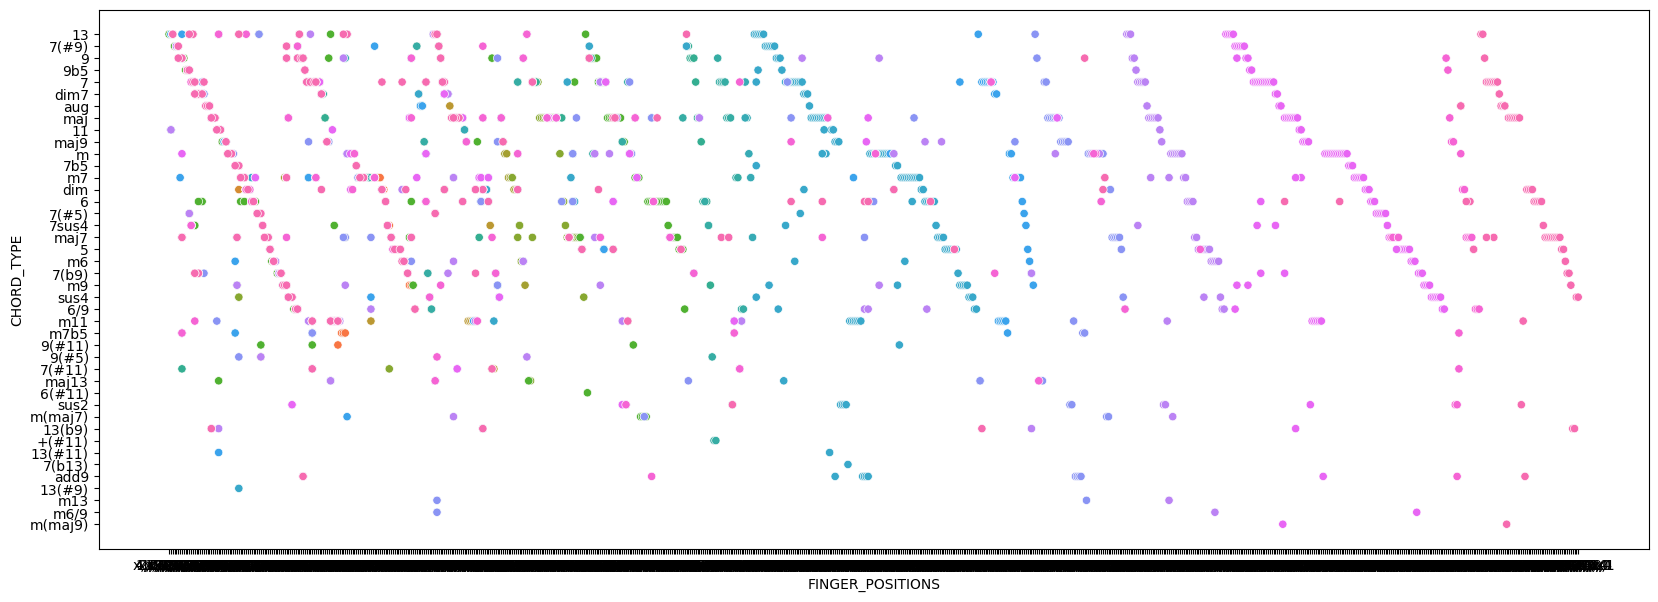

In [ ]:
sns.scatterplot(data=df, x='FINGER_POSITIONS', y='CHORD_TYPE',hue= 'CHORD_ROOT',legend = False )

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical features into numerical values
encoder = LabelEncoder()

encoded_CHORD_ROOT = encoder.fit_transform(df.CHORD_ROOT)
encoded_CHORD_TYPE = encoder.fit_transform(df.CHORD_TYPE)
encoded_FINGER_POSITIONS = encoder.fit_transform(df.FINGER_POSITIONS)
encoded_NOTE_NAMES = encoder.fit_transform(df.NOTE_NAMES)

In [ ]:
encoded_df = pd.DataFrame({
  'encoded_CHORD_ROOT': encoded_CHORD_ROOT,
  'encoded_CHORD_TYPE': encoded_CHORD_TYPE,
  'encoded_FINGER_POSITIONS': encoded_FINGER_POSITIONS,
  'encoded_NOTE_NAMES': encoded_NOTE_NAMES
})

In [ ]:
encoded_df.head()

,encoded_CHORD_ROOT,encoded_CHORD_TYPE,encoded_FINGER_POSITIONS,encoded_NOTE_NAMES
0,1,2,424,17
1,1,2,311,60
2,1,2,176,65
3,1,13,427,15
4,1,13,215,15


In [ ]:
df.head()

,CHORD_ROOT,CHORD_TYPE,CHORD_STRUCTURE,FINGER_POSITIONS,NOTE_NAMES
0,A#,13,1;3;5;b7;9;11;13,"x,1,0,2,3,4","A#,C##,G#,B#,F##"
1,A#,13,1;3;5;b7;9;11;13,"4,x,3,2,1,1","A#,G#,B#,C##,F##"
2,A#,13,1;3;5;b7;9;11;13,"1,x,1,2,3,4","A#,G#,C##,F##,B#"
3,A#,7(#9),1;3;5;b7;#9,"x,1,0,2,4,3","A#,C##,G#,B##,E#"
4,A#,7(#9),1;3;5;b7;#9,"2,1,3,3,3,x","A#,C##,G#,B##,E#"




---



> **Machine Learning**



---






---


**Supervised**


---



In [ ]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

features = ['encoded_CHORD_TYPE', 'encoded_FINGER_POSITIONS', 'encoded_NOTE_NAMES']

x = encoded_df[features]
y = df['CHORD_ROOT']

# Split data into Train and Test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model_dtree = DecisionTreeClassifier()
model_dtree = model_dtree.fit(x_train,y_train)

# Predict on Test set
y_pred = model_dtree.predict(x_test)
print("Accuracy = ",accuracy_score(y_test , y_pred)*100,"%")

Accuracy =  75.71157495256166 %


[Text(0.16339526130157767, 0.9761904761904762, 'encoded_NOTE_NAMES <= 276.5\ngini = 0.934\nsamples = 2105\nvalue = [192, 61, 111, 123, 159, 187, 109, 1, 174, 57, 95\n173, 106, 134, 94, 178, 83, 68]'),
 Text(0.04514563106796116, 0.9285714285714286, 'encoded_NOTE_NAMES <= 67.5\ngini = 0.624\nsamples = 266\nvalue = [151, 50, 0, 9, 1, 1, 0, 0, 33, 4, 0, 0, 0, 9\n8, 0, 0, 0]'),
 Text(0.014563106796116505, 0.8809523809523809, 'encoded_NOTE_NAMES <= 0.5\ngini = 0.249\nsamples = 58\nvalue = [0, 50, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0\n5, 0, 0, 0]'),
 Text(0.01262135922330097, 0.8333333333333334, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0\n0, 0, 0, 0]'),
 Text(0.01650485436893204, 0.8333333333333334, 'encoded_NOTE_NAMES <= 53.5\ngini = 0.222\nsamples = 57\nvalue = [0, 50, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0\n5, 0, 0, 0]'),
 Text(0.009708737864077669, 0.7857142857142857, 'encoded_FINGER_POSITIONS <= 714.5\ngini = 0.132\nsamples = 43\nvalue = [0, 40, 0, 0, 0, 0, 0, 

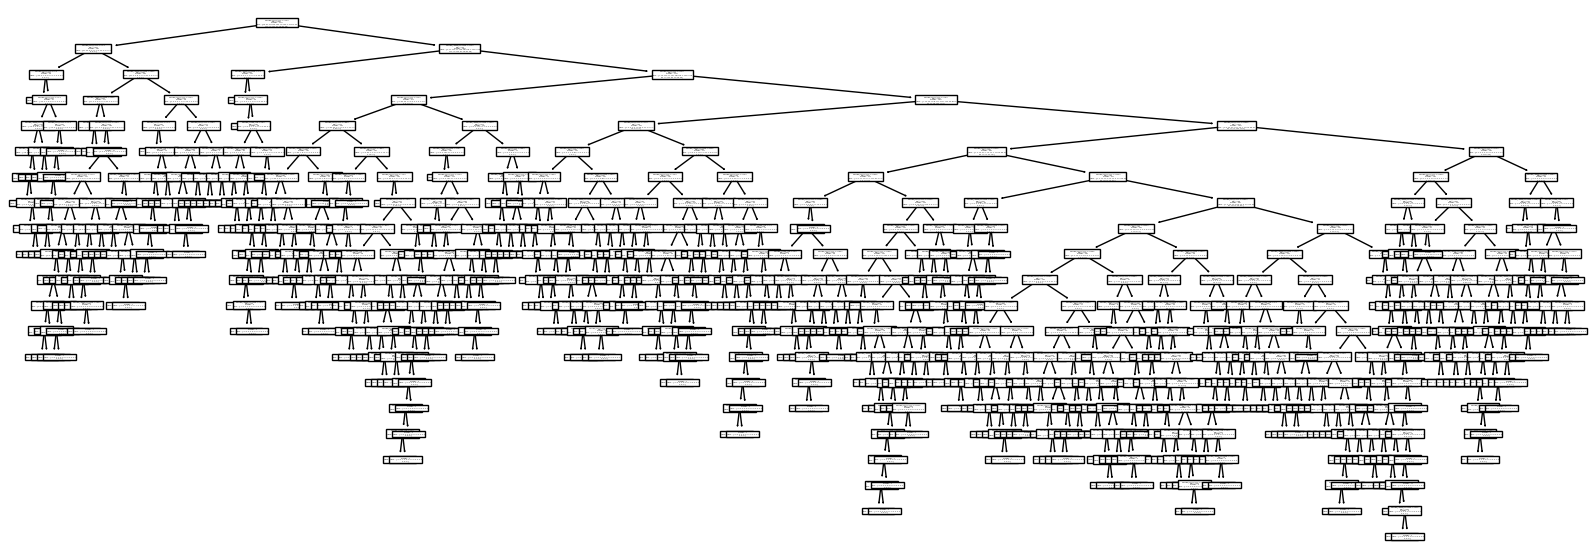

In [ ]:
plt.rcParams['figure.figsize'] = (20,7)
plt.savefig("aa.png")

tree.plot_tree(model_dtree, feature_names=features)

In [ ]:
encoded_df

,encoded_CHORD_ROOT,encoded_CHORD_TYPE,encoded_FINGER_POSITIONS,encoded_NOTE_NAMES
0,1,2,424,17
1,1,2,311,60
2,1,2,176,65
3,1,13,427,15
4,1,13,215,15
...,...,...,...,...
2627,15,41,450,2026
2628,15,41,730,1975
2629,15,9,208,1928
2630,15,9,698,1926


In [ ]:
encoded_df.iloc[0:1,0:4]

,encoded_CHORD_ROOT,encoded_CHORD_TYPE,encoded_FINGER_POSITIONS,encoded_NOTE_NAMES
0,1,2,424,17


In [ ]:
df.iloc[0:1,0:4]

,CHORD_ROOT,CHORD_TYPE,FINGER_POSITIONS,NOTE_NAMES
0,A#,13,"x,1,0,2,3,4","A#,C##,G#,B#,F##"


In [ ]:
encoded_df.iloc[2627:2628,0:4]

,encoded_CHORD_ROOT,encoded_CHORD_TYPE,encoded_FINGER_POSITIONS,encoded_NOTE_NAMES
2627,15,41,450,2026


In [ ]:
df.iloc[2627:2628,0:4]

,CHORD_ROOT,CHORD_TYPE,FINGER_POSITIONS,NOTE_NAMES
2627,G,sus4,"x,1,2,3,4,1","G,D,G,C,D"


In [ ]:
print("No.0 =",model_dtree.predict([[2,424,17]]))
print("No.2627 =",model_dtree.predict([[41,450,2026]]))

No.0 = ['A#']
No.2627 = ['G']


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(




---




 **Unsupervised**







---



In [ ]:
df.CHORD_ROOT.unique()

array(['A#', 'C#', 'D#', 'F#', 'G#', 'Ab', 'Bb', 'Cb', 'Db', 'Eb', 'Gb',
       'A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype=object)

In [ ]:
df.CHORD_ROOT.unique().shape

(18,)

In [ ]:
encoded_df

,encoded_CHORD_ROOT,encoded_CHORD_TYPE,encoded_FINGER_POSITIONS,encoded_NOTE_NAMES
0,1,2,424,17
1,1,2,311,60
2,1,2,176,65
3,1,13,427,15
4,1,13,215,15
...,...,...,...,...
2627,15,41,450,2026
2628,15,41,730,1975
2629,15,9,208,1928
2630,15,9,698,1926


encoded_CHORD_TYPE value [2, 2, 2, 13, 13, 13, 18, 18, 18, 21, 21, 21, 10, 10, 10, 25, 25, 25, 25, 25, 25, 25, 25, 23, 23, 23, 36, 36, 36, 1, 1, 1, 39, 39, 39, 26, 26, 26, 26, 16, 16, 16, 33, 33, 33, 24, 24, 24, 7, 7, 7, 12, 12, 12, 17, 17, 17, 38, 38, 38, 6, 31, 31, 31, 15, 15, 15, 35, 35, 35, 41, 41, 41, 9, 9, 9, 2, 2, 2, 13, 13, 13, 18, 18, 18, 18, 18, 21, 21, 21, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 23, 23, 23, 36, 36, 36, 36, 36, 1, 1, 1, 39, 39, 39, 29, 29, 29, 29, 29, 29, 29, 34, 34, 34, 34, 34, 34, 26, 26, 26, 26, 26, 26, 26, 26, 16, 16, 16, 19, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 24, 24, 24, 24, 24, 7, 7, 7, 12, 12, 12, 17, 17, 17, 17, 38, 38, 38, 6, 6, 6, 6, 6, 31, 31, 31, 31, 15, 15, 15, 35, 35, 35, 35, 35, 35, 41, 41, 41, 9, 9, 9, 2, 2, 2, 13, 13, 13, 18, 18, 18, 21, 21, 21, 10, 10, 10, 10, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 23, 23, 23, 36, 36, 36, 1, 1, 1, 39, 39, 39, 29, 26, 26, 26

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


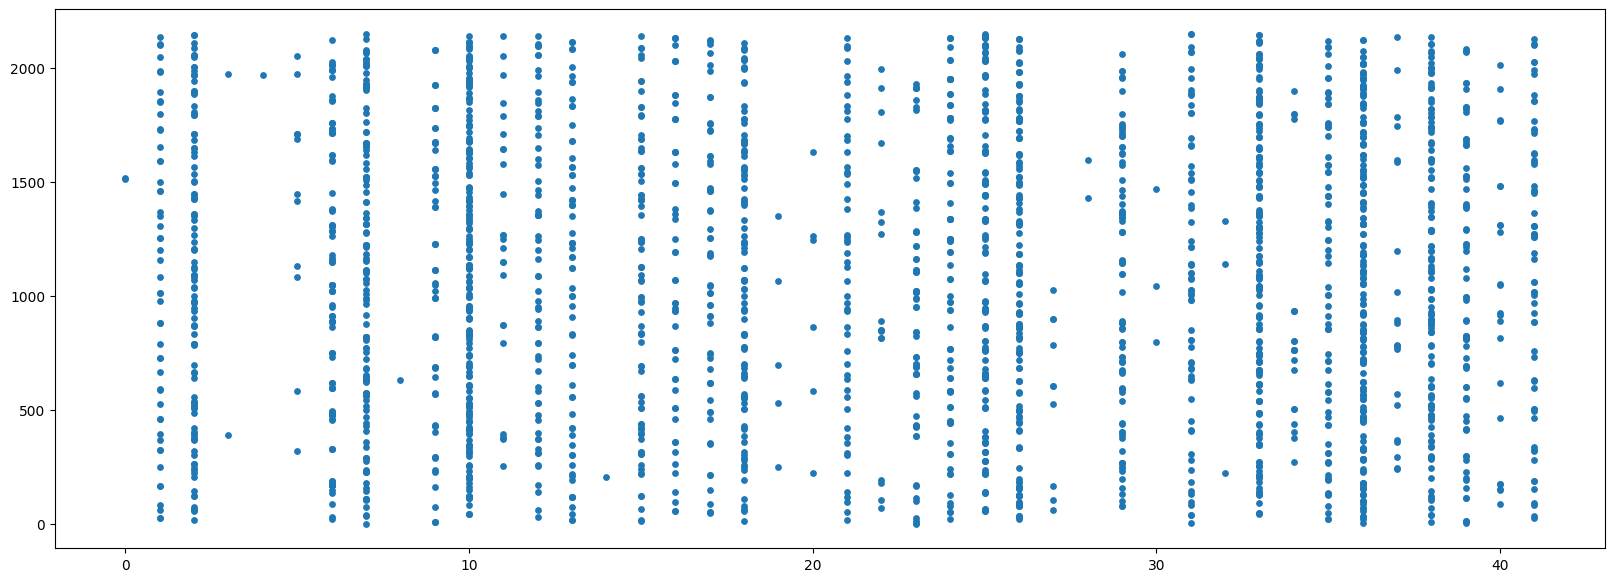

In [ ]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage

x = encoded_df['encoded_CHORD_TYPE'].tolist()
y = encoded_df['encoded_NOTE_NAMES'].tolist()

print(f"encoded_CHORD_TYPE value {x}")
print(f"encoded_NOTE_NAMES value {y}")
data = list(zip(x,y))

Cluster_Count = 18

hierarchical_cluster = AgglomerativeClustering(n_clusters=Cluster_Count, affinity='euclidean', linkage='ward')
labels = hierarchical_cluster.fit_predict(data)

plt.scatter(encoded_df['encoded_CHORD_TYPE'],encoded_df['encoded_NOTE_NAMES'],s=15)
plt.show()


In [ ]:
krange = range(1,20)
sse = []
for i in krange:
  m = KMeans(i)
  m.fit(encoded_df[['encoded_CHORD_TYPE','encoded_NOTE_NAMES']])
  sse.append(m.inertia_)

model_kmeans = KMeans(n_clusters = 18)
model_kmeans.fit(encoded_df[['encoded_CHORD_TYPE','encoded_NOTE_NAMES']])

y = model_kmeans.predict(encoded_df[['encoded_CHORD_TYPE','encoded_NOTE_NAMES']])

encoded_df['Cluster'] = y
encoded_df

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

,encoded_CHORD_ROOT,encoded_CHORD_TYPE,encoded_FINGER_POSITIONS,encoded_NOTE_NAMES,Cluster
0,1,2,424,17,0
1,1,2,311,60,0
2,1,2,176,65,0
3,1,13,427,15,0
4,1,13,215,15,0
...,...,...,...,...,...
2627,15,41,450,2026,14
2628,15,41,730,1975,14
2629,15,9,208,1928,11
2630,15,9,698,1926,11


In [ ]:
Predict_input1 = [2,17]

PredictValue = model_kmeans.predict([[Predict_input1[0],Predict_input1[1]]])

print(f"The prediction from Length = {Predict_input1[0]}, Width = {Predict_input1[1]} is cluster group {PredictValue + 1}")

The prediction from Length = 2, Width = 17 is cluster group [1]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


Unsupervised Machine Learning Results

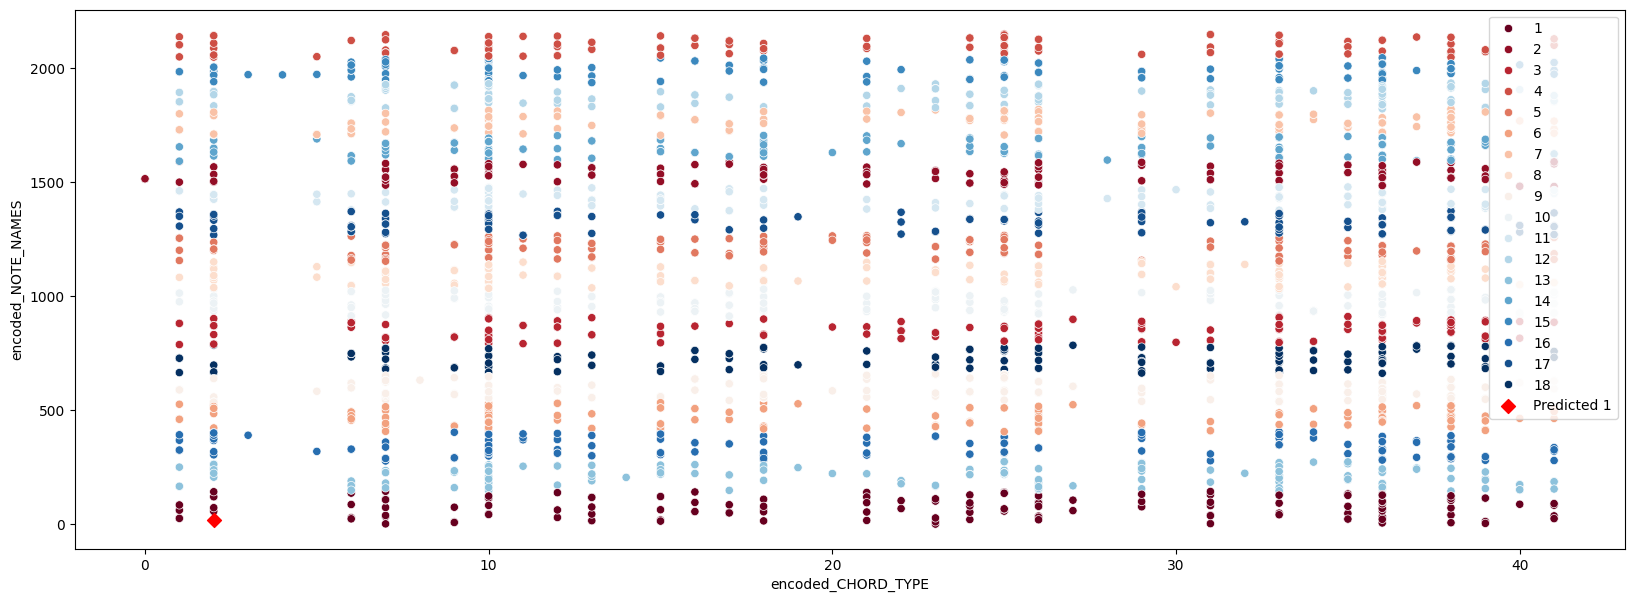

In [ ]:
sns.scatterplot(data=encoded_df, x="encoded_CHORD_TYPE", y="encoded_NOTE_NAMES", hue=encoded_df.Cluster+1, legend="full",palette='RdBu')
plt.scatter(Predict_input1[0],Predict_input1[1],color ='red',label = 'Predicted 1',marker ='D',s=50)
plt.legend(loc='upper right')




---


> **Data Visualization**



---



In [ ]:
df.columns

Index(['CHORD_ROOT', 'CHORD_TYPE', 'FINGER_POSITIONS', 'NOTE_NAMES'], dtype='object')

In [ ]:
df.CHORD_ROOT.unique()

array(['A#', 'C#', 'D#', 'F#', 'G#', 'Ab', 'Bb', 'Cb', 'Db', 'Eb', 'Gb',
       'A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype=object)

In [ ]:
chord_counts = df['CHORD_ROOT'].value_counts()

print(chord_counts)
chord_counts.sum()

CHORD_ROOT
A     233
C     226
G     224
D     223
E     220
Bb    197
F     170
B     153
C#    134
Ab    132
Eb    129
F#    126
Db    116
G#     98
Gb     92
D#     82
A#     76
Cb      1
Name: count, dtype: int64


2632

In [ ]:
chord_counts.index

Index(['A', 'C', 'G', 'D', 'E', 'Bb', 'F', 'B', 'C#', 'Ab', 'Eb', 'F#', 'Db',
       'G#', 'Gb', 'D#', 'A#', 'Cb'],
      dtype='object', name='CHORD_ROOT')

In [ ]:
chord_counts.values

array([233, 226, 224, 223, 220, 197, 170, 153, 134, 132, 129, 126, 116,
        98,  92,  82,  76,   1])

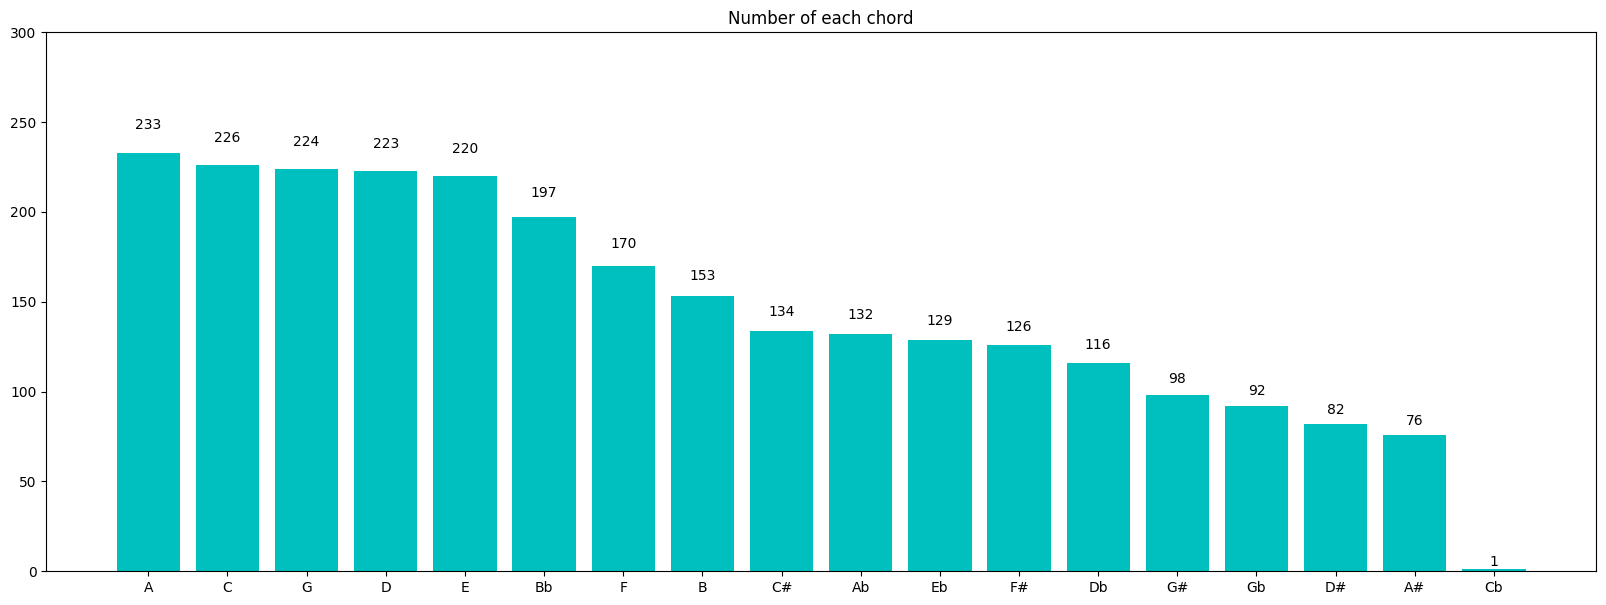

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

#Set Value & Label of axis
bar_x = [int(i) for i in  range(1,19)] #Value of x-axis
bar_height = chord_counts.values #Value of y-axis
bar_tick_label = chord_counts.index #Labal of x-axis
bar_label = chord_counts.values #Label of y-axis

#Ploting Bar Chart
bar_plot = plt.bar(bar_x,bar_height,tick_label=bar_tick_label, color='c')

#creating Add Label Function
def autolabel(rects):
    for idx,rect in enumerate(bar_plot):
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., 1.05*height,
                bar_label[idx],
                ha='center', va='bottom', rotation=0)
autolabel(bar_plot)

plt.ylim(0,300)

plt.title('Number of each chord')

plt.show()

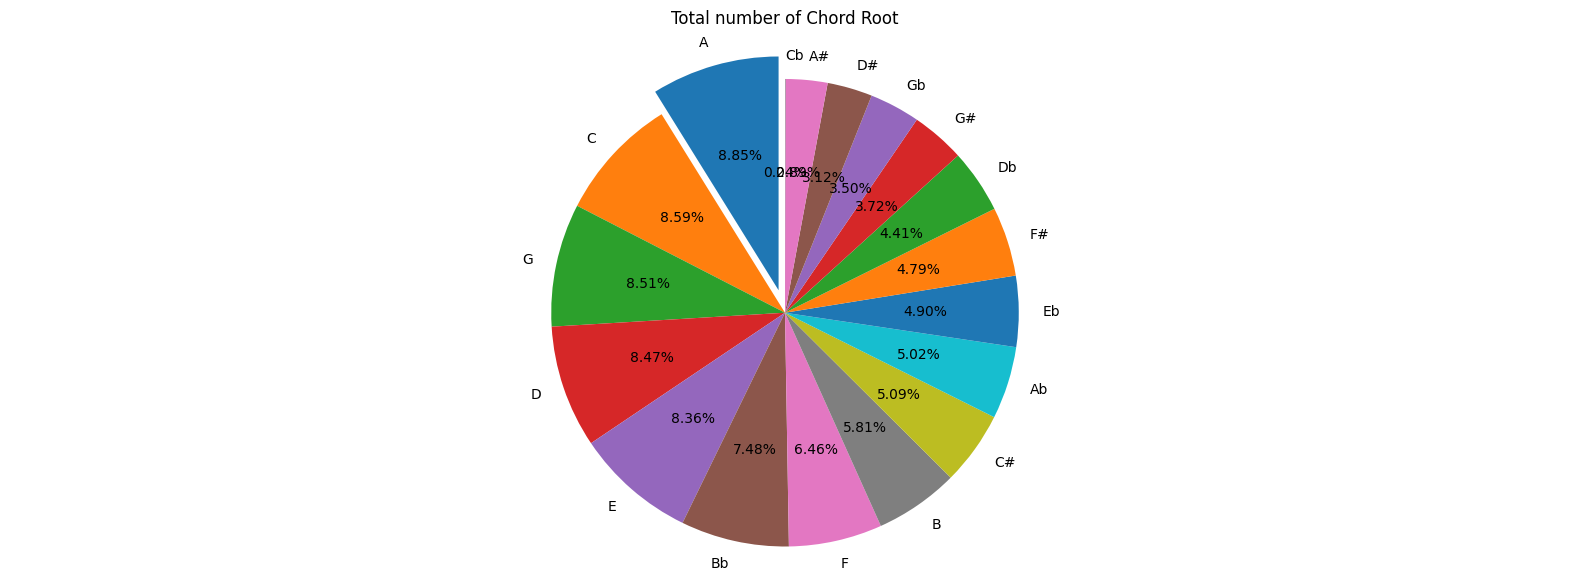

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
#Set Labels
labels = chord_counts.index
sections = chord_counts.values
#Ploting Pie Chart
plt.pie(sections, labels=labels,
        startangle=90,
        explode=(0.1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0),
        autopct='%1.2f%%')

plt.axis('equal')

plt.title('Total number of Chord Root')

plt.show()

In [ ]:
chord_type_counts = df.CHORD_TYPE.value_counts()

print(chord_type_counts)
chord_type_counts.sum()

CHORD_TYPE
7          208
maj        203
m7         177
m          154
dim7       142
maj7       137
6          134
13         113
5          108
9          105
dim         86
m11         82
7(b9)       81
m9          74
maj9        70
aug         69
7(#9)       68
m6          66
7(#5)       64
6/9         64
sus4        63
7sus4       58
7b5         51
11          51
9b5         51
7(#11)      24
sus2        22
m7b5        21
maj13       21
add9        17
13(b9)      12
m(maj7)     10
9(#5)        6
9(#11)       5
m13          3
m6/9         3
+(#11)       2
13(#11)      2
m(maj9)      2
6(#11)       1
7(b13)       1
13(#9)       1
Name: count, dtype: int64


2632

In [ ]:
chord_type_counts.index

Index(['7', 'maj', 'm7', 'm', 'dim7', 'maj7', '6', '13', '5', '9', 'dim',
       'm11', '7(b9)', 'm9', 'maj9', 'aug', '7(#9)', 'm6', '7(#5)', '6/9',
       'sus4', '7sus4', '7b5', '11', '9b5', '7(#11)', 'sus2', 'm7b5', 'maj13',
       'add9', '13(b9)', 'm(maj7)', '9(#5)', '9(#11)', 'm13', 'm6/9', '+(#11)',
       '13(#11)', 'm(maj9)', '6(#11)', '7(b13)', '13(#9)'],
      dtype='object', name='CHORD_TYPE')

In [ ]:
chord_type_counts.values

array([208, 203, 177, 154, 142, 137, 134, 113, 108, 105,  86,  82,  81,
        74,  70,  69,  68,  66,  64,  64,  63,  58,  51,  51,  51,  24,
        22,  21,  21,  17,  12,  10,   6,   5,   3,   3,   2,   2,   2,
         1,   1,   1])

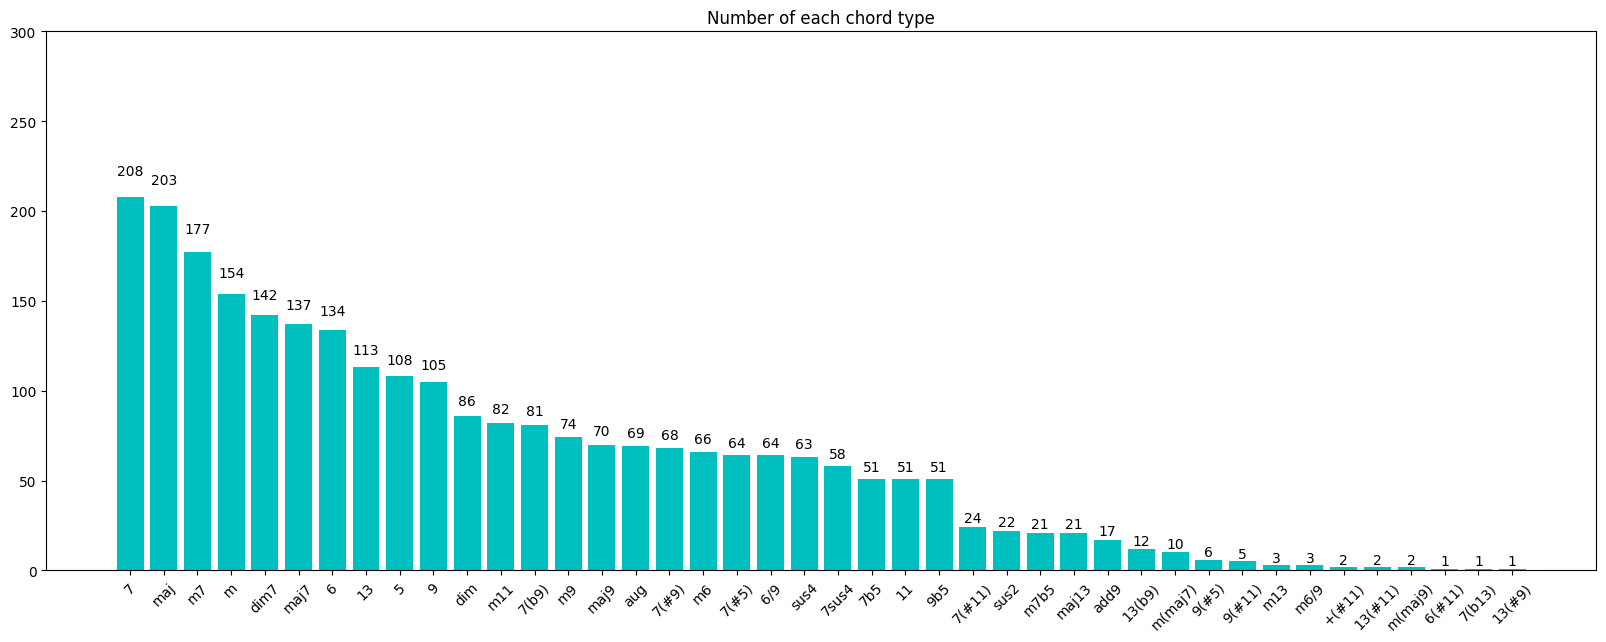

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

#Set Value & Label of axis
bar_x = [int(i) for i in range(1, 43)] #Value of x-axis
bar_height = chord_type_counts.values #Value of y-axis
bar_tick_label = chord_type_counts.index #Labal of x-axis
bar_label = chord_type_counts.values #Label of y-axis

#Ploting Bar Chart
bar_plot = plt.bar(bar_x,bar_height,tick_label=bar_tick_label, color='c')

#creating Add Label Function
def autolabel(rects):
    for idx,rect in enumerate(bar_plot):
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., 1.05*height,
                bar_label[idx],
                ha='center', va='bottom', rotation=0)
autolabel(bar_plot)

plt.ylim(0,300)

plt.title('Number of each chord type')

plt.xticks(rotation=45)
plt.show()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41],
 [Text(0, 0, '13'),
  Text(1, 0, '7(#9)'),
  Text(2, 0, '9'),
  Text(3, 0, '9b5'),
  Text(4, 0, '7'),
  Text(5, 0, 'dim7'),
  Text(6, 0, 'aug'),
  Text(7, 0, 'maj'),
  Text(8, 0, '11'),
  Text(9, 0, 'maj9'),
  Text(10, 0, 'm'),
  Text(11, 0, '7b5'),
  Text(12, 0, 'm7'),
  Text(13, 0, 'dim'),
  Text(14, 0, '6'),
  Text(15, 0, '7(#5)'),
  Text(16, 0, '7sus4'),
  Text(17, 0, 'maj7'),
  Text(18, 0, '5'),
  Text(19, 0, 'm6'),
  Text(20, 0, '7(b9)'),
  Text(21, 0, 'm9'),
  Text(22, 0, 'sus4'),
  Text(23, 0, '6/9'),
  Text(24, 0, 'm11'),
  Text(25, 0, 'm7b5'),
  Text(26, 0, '9(#11)'),
  Text(27, 0, '9(#5)'),
  Text(28, 0, '7(#11)'),
  Text(29, 0, 'maj13'),
  Text(30, 0, '6(#11)'),
  Text(31, 0, 'sus2'),
  Text(32, 0, 'm(maj7)'),
  Text(33, 0, '13(b9)'),


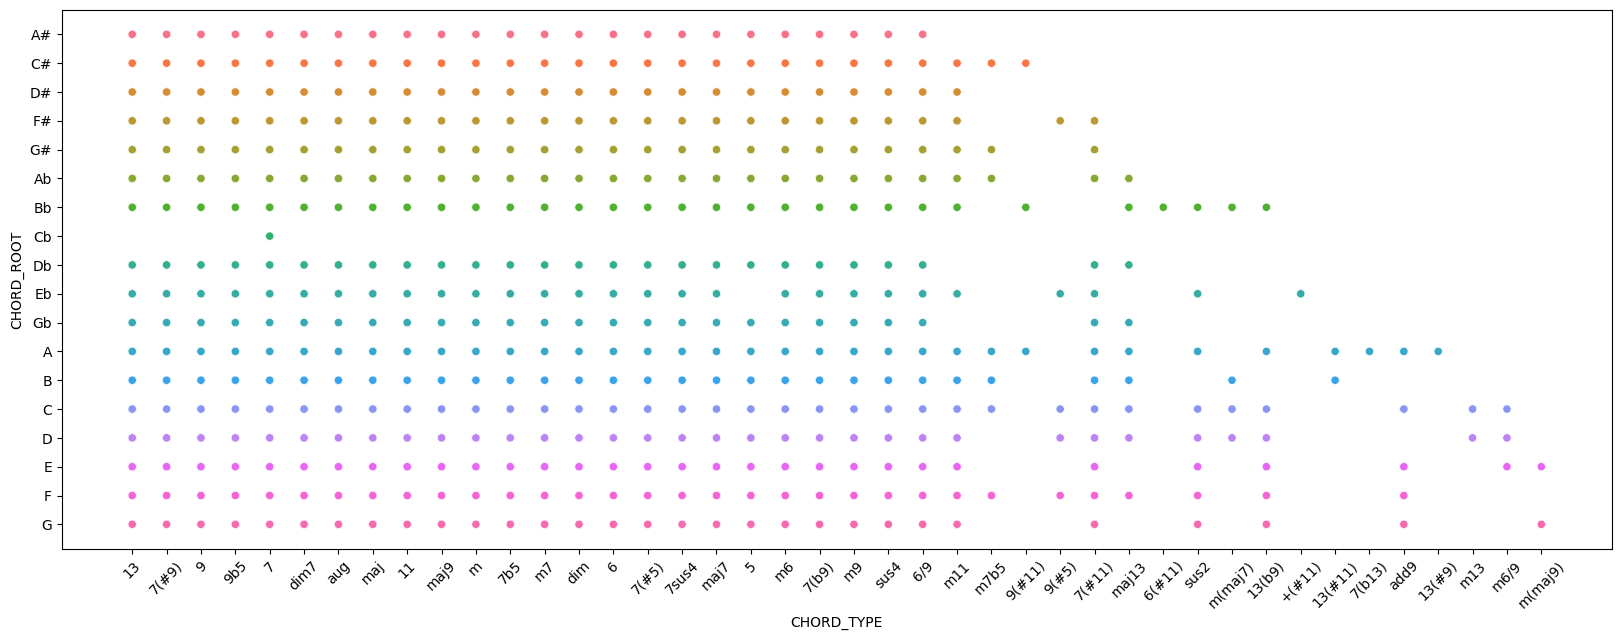

In [ ]:
sns.scatterplot(data=df, x='CHORD_TYPE', y='CHORD_ROOT',hue= 'CHORD_ROOT',legend = False)
plt.xticks(rotation=45)